
# DL Final Exam

**Name:** Joyant Sheikhar Gupta Joy

**Course Email:**  joyantsheikharguptajoy@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

## Explain the concept of backpropagation in detail. Describe how the error is propagated from the output layer to the hidden layers. Derive the mathematical expressions for weight updates using the chain rule, and explain how learning rate affects the training process.


# Write Answer 01:

### **Backpropagation in Neural Networks**

Backpropagation is a supervised learning algorithm used in neural networks to reduce error and improve prediction accuracy. It works by calculating how much each weight contributes to the error and then updating the weights using gradient descent.

### **1. Concept of Backpropagation**

Backpropagation has two main steps:
* Forward Pass: Input moves through the network to produces output.
* Backward Pass: Error is calculated at the output and then propagated backward to update weights in hidden layers.

### **2. Forward Computation**

* For a single neuron:
$$ z = wx+b $$
$$ a=f(z) $$

Where:
* $w =$ weight
* $x =$ input
* $b =$ bias
* $f =$ activation function
* $a =$ output

Finally, we get the predicted output. Now Compare predicted output with actual output using a loss function. Example (Mean Squared Error)
$$
L = \frac{1}{2}(y-a)^2
$$

Where:
* $y =$ actual value
* $a =$ predicted value

### **3. Error Propagation (Backward Flow)**

Backpropagation calculates how loss changes with respect to weights:
$$
\frac{∂L}{∂w}
$$
This is done using the chain rule because loss depends indirectly on weights through multiple steps.

### **4. Chain Rule Derivation**

$$
\frac{∂L}{∂w} = \frac{∂L}{∂a} ⋅ \frac{∂a}{∂z} \cdot \frac{∂z}{∂w}
$$

Now compute each part:

**Loss Derivative:**
$$
L = \frac{1}{2}(y-a)^2
$$

$$
\frac{∂L}{∂a} = (a-y)
$$

This measures how much the loss changes when the prediction $a$ changes. It represents the prediction error.

**Activation Derivative:**

$$
\frac{∂a}{∂z} = f^\prime(z)
$$

This shows how the activation output changes with respect to the input $z$. It depends on the activation function slope.

**Linear Derivative**

$$
z = wx + b ⇒\frac{∂z}{∂w} = x
$$

This tells how the weighted sum $z$ changes when the weight $w$ changes. It depends directly on the input value $x$.

**Final Gradient**

$$
\frac{∂L}{∂w} = (a - y) ⋅ f^\prime(z) ⋅ x
$$

### **5. Error Signal (Delta)**

We define:

$$
δ = \frac{∂L}{∂z}
$$

So,

$$
δ = (a - y) ⋅ f^\prime(z)
$$

Now gradient becomes:

$$
\frac{∂L}{∂w} = δx
$$

$$
\frac{∂L}{∂b} = δ
$$

###**6. Weight Update Rule**

Weights are updated using gradient descent:

$$
w = w - η\frac{∂L}{∂w}
$$

Where, $η =$ learning rate

So,

$$
w = w - \eta(δx)
$$

Bias update:

$$
b = b - ηδ
$$

### **7. Role of Learning Rate $(\eta)$**

The Learning rate controls the size of the steps taken during weight updates in training. If the learning rate is too large, the model may learn quickly but it can overshoot the optimal solution and become unstable. On the other hand, if the learning rate is too small, the training process becomes very slow, although it is more stable and accurate. Therefore, a balanced learning rate is important because it allows the model to converge smoothly and reach the minimum loss efficiently.

### **8. Learning Rate Comparison (Small, Large, Balanced)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load FULL dataset
# -----------------------------
data = fetch_california_housing()

X = data.data
y = data.target.reshape(-1, 1)

# -----------------------------
# 2. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2. Feature Scaling
# -----------------------------
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# -----------------------------
# 4. Neural Network Model
# -----------------------------
class HouseModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    )

  def forward(self, x):
    return self.model(x)

criterion = nn.MSELoss()

# -----------------------------
# 5. Create 3 models
# -----------------------------
model_small = HouseModel()
model_balanced = HouseModel()
model_large = HouseModel()

# optimizers with different learning rates
opt_small = optim.SGD(model_small.parameters(), lr=0.0001)
opt_balanced = optim.SGD(model_balanced.parameters(), lr=0.01)
opt_large = optim.SGD(model_large.parameters(), lr=0.5)

# -----------------------------
# 6. Training Loop Fucntion
# -----------------------------
def train(model, optimizer, name):
  print(f"\n=== {name} ===")
  for epoch in range(100):
    model.train()
    # gradient resets
    optimizer.zero_grad()

    # predicted output
    pred = model(X_train)

    # Loss computation
    loss = criterion(pred, y_train)

    # backward pass
    loss.backward()

    # update parameters
    optimizer.step()

    if (epoch +1) % 20 == 0:
      print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}")

# -----------------------------
# 7. Train all models
# -----------------------------
train(model_small, opt_small, "Small LR (0.0001)")
train(model_balanced, opt_balanced, "Balanced LR (0.01)")
train(model_large, opt_large, "Large LR (0.5)")


=== Small LR (0.0001) ===
Epoch 20, Loss: 1.03066
Epoch 40, Loss: 1.03003
Epoch 60, Loss: 1.02940
Epoch 80, Loss: 1.02878
Epoch 100, Loss: 1.02817

=== Balanced LR (0.01) ===
Epoch 20, Loss: 0.97316
Epoch 40, Loss: 0.95854
Epoch 60, Loss: 0.94300
Epoch 80, Loss: 0.92534
Epoch 100, Loss: 0.90442

=== Large LR (0.5) ===
Epoch 20, Loss: 0.70709
Epoch 40, Loss: 0.71484
Epoch 60, Loss: 1.00011
Epoch 80, Loss: 1.00004
Epoch 100, Loss: 1.00001


**Explanation:** From these results, we can observe how different learning rates affect the training process of the model. With a very small learning rate of 0.0001, the loss decreases very slowly over time, which means the model is learning but at a very slow speed. In the case of the balanced learning rate 0.01, the loss decreases more steadily and consistently, showing stable and smooth learning behavior. For the large learning rate 0.5, the loss drops quickly at some points, but it is not stable and shows fluctuation, which indicates that the training process is not consistent and may overshoot the optimal solution. Overall, the balanced learning rate provides the most reliable and effective learning performance among the three.

# Question 02: [ Marks 10 ]

## Consider a neural network with one hidden layer using sigmoid activation. Derive the complete backpropagation equations for updating weights and biases. Show all steps clearly, including forward pass, loss calculation, and backward pass.

## Write Answer 02:

## **Backpropagation for a Neural Network (One Hidden Layer, Sigmoid Activation)**

We consider a neural network with:
* Input layer
* One hidden layer
* One Output layer
* Sigmoid activation function

### **1. Notations**
* Input: $x$
* Hidden layer weights: $w_1$, bias: $b_1$
* Output layer weights: $w_2$, bias: $b_2$
* Hidden output: $a$
* Final output: $\hat{y}$
* Actual value: $y$

Sigmoid function;

$$
σ(z) = \frac{1}{1+e^{-z}}
$$

Derivative,

$$
σ^\prime(z) = σ(z)(1-σ(z))
$$


### **2. Forward Pass**

Hidden Layer

$$
z_1 = w_1x + b_1
$$

$$
a = σ(z_1)
$$

Output Layer

$$
z_2 = w_2a + b_2
$$

$$
\hat{y} = σ(z_2)
$$

###**3. Loss Function**

Using Mean Squared Error(MSE):

$$
L = \frac{1}{2}(y-\hat{y})^2
$$

###**4. Backward Pass (Using Chain Rule)**

**Step 1: Output Layer Error**

We compute:

$$
δ_2 = \frac{∂L}{∂z_2}
$$

Using chain rule:

$$
δ_2 =  \frac{∂L}{∂\hat{y}} ⋅ \frac{∂\hat{y}}{∂z_2}
$$

Now,

$$
\frac{∂L}{∂\hat{y}} = (\hat{y}-y)
$$

$$
\frac{∂\hat{y}}{∂z_2} = σ^\prime(z_2)
$$

So,

$$
δ_2 = (\hat{y}-y) ⋅ σ^\prime(z_2)
$$

**Step 2: Gradients for Output Layer**

Weight:

$$
\frac{∂L}{∂w_2} = δ_2 ⋅ a
$$

Bias:

$$
\frac{∂L}{∂b_2} = δ_2
$$

**Step 3: Hidden Layer Error**

Error is propagated backward:

$$
δ_1 = \frac{∂L}{∂z_1}
$$

Using chain rule:

$$
δ_1 = \frac{∂L}{∂z_2} ⋅ \frac{∂z_2}{∂a} ⋅ \frac{∂a}{∂z_1}
$$

Now,

$$
\frac{∂L}{∂z_2} = δ_2
$$

$$
\frac{∂z_2}{∂a} = w_2
$$

$$
\frac{∂a}{∂z_1} = σ^\prime(z_1)
$$

So,

$$
δ_1 = (w_2 ⋅ δ_2) ⋅ σ^\prime(z_1)
$$

**Step 4: Gradients for Hidden Layer**

Weight:

$$
\frac{∂L}{∂w_1} = δ_1 ⋅ x
$$

Bias:

$$
\frac{∂L}{∂b_1} = δ_1
$$

###**5. Weight and Bias Update Rules**

Using gradient descent:

$$
w_2 = w_2 - η ⋅ (δ_2 ⋅ a)
$$

$$
b_2 = b_2 - \eta ⋅ δ_2
$$

$$
w_1 = w_1 - η ⋅ (δ_1 ⋅ x)
$$

$$
b_1 = b_1 - \eta ⋅ δ_1
$$

Where:
* $\eta =$ learning rate


# Question 03: [Marks 5]

## Discuss the vanishing gradient problems in deep neural networks. Explain why they occur during backpropagation, how activation functions contribute to this issue, and suggest at least three techniques to overcome these problems.


## Write Answer 03:

### **Vanishing Gradient Problem in Deep Neural Networks**

The vanishing gradient problem is a common issue in deep neural networks where the gradients become extremely small during backpropagation. As a result, the weights in earlier layers are updated very slowly or sometimes almost not at all. This makes training deep networks difficult.

### **Why it occurs during backpropagation**

During backpropagation, gradients are calculated using the chain rule. This means derivatives from each layer are multiplied together. In deep networks, this multiplication happens many times. If the values being multiplied are small (less than 1), the final gradient becomes extremely small. As a result, the gradients become nearly zero in earlier layers, and learning becomes very slow.

### **Role of Activation Function**

Activation functions like sigmoid and tanh make this problem worse. Their derivatives are always small (for sigmoid, maximum value is 0.25). When these small values are multiplied across many layers, the gradient keeps shrinking and eventually vanishes before reaching the first layers.

### **Techniques to Overcome Vanishing Gradient**

1. One effective solution is to use GELU (Gaussian Error Linear Unit) activation. It is smoother than ReLU and maintains better gradient flow compared to sigmoid or tanh, helping deeper networks learn more effectively.

2. Another method is proper weight initialization, such as Xavier or He initialization. This helps keep the gradients in a reasonable range at the start of training.

3. Batch normalization is also useful because it normalizes the inputs of each layer and makes training more stable.

4. Residual connections (skip connections) can be used to allow gradients to pass directly through layers, which helps reduce the vanishing effect.

# Question 04: [ Marks 5 ]

## Describe the architecture of an Artificial Neural Network (ANN) in detail. Explain the role of each component (neurons, weights, bias, activation functions). Also discuss how increasing the number of hidden layers and neurons affects model performance and overfitting.


## Write Answer 04:

### **Architecture of an Artificial Neural Network (ANN)**

An Artificial Neural Network (ANN) is a model inspired by the human brain. It is made up of layers of connected nodes called neurons. A typical ANN has three main parts: an input layer, one or more hidden layers and an output layer. The input layer receives the data, the hidden layers process it, and the output layer gives the final result.

### **Main Components and Their Roles**

**Neurons:** Neurons are the basic units of a neural network. Each neuron takes some inputs, perform a calculation, and produce output. It works like a small processing unit.

**Weights:** Weights are values assigned to each input connection. They control how important each input is. During training, these weights are adjusted so that the model can make better predictions.

**Bias:** Bias is an extra value added to the neuron's calculation. It helps the model shift the output and gives more flexibility. Without bias, the model may not fit the data properly.

**Activation Function:** After calculating the weighted sum, an activation function is applied. It decides whether the neuron should be activated or not. It also adds non-linearity, which allows the network to learn complex patterns. Common examples include ReLU, sigmoid, and GELU.

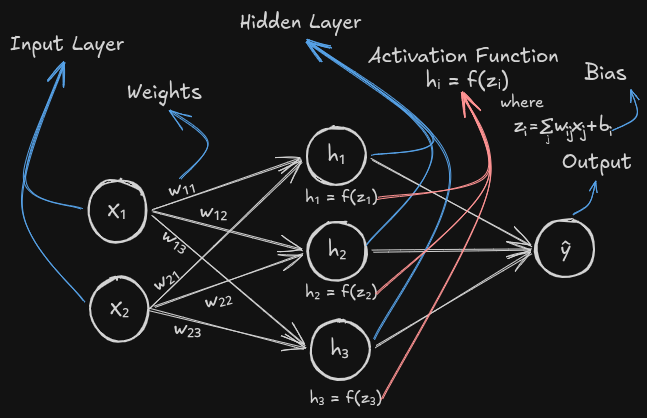

### **Effect of Increasing Hidden Layers and Neurons**

When we increase the number of hidden layers of neurons, the model becomes more powerful and can learn complex patterns from the data. This usually improves performance, especially for difficult problems.

However, if the network becomes too large, it may start to memorize the training data instead of learning general patterns. This called overfitting. In such cases, the model performs well on training data but poorly on new, unseen data.

So, it is important to choose a balanced number of layers and neurons. A model should be complex enough to learn the data but not so large that it overfits.

# Question 05: [ Marks 10 ]

## Compare Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) in detail. Discuss their architectures, working principles, advantages, limitations, and typical use cases such as image processing, tabular data, and pattern recognition.

## Write Answer 05:

### **Comparison between ANN and CNN**

Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) are both deep learning models, but they are designed for different types of problems. ANN is more general, while CNN is specially designed for processing image and spatial data.

### **1. Architecture**

**ANN (Artificial Neural Network)**: ANN is made of fully connected layers where every neuron in one layer is connected to every neuron in the next layer. It usually has an input layer, one or more hidden layers, and an output layer. It works well with structured data like tabular datasets.

**CNN (Convolutional Neural Networks)**: CNN has different structure. It includes convolutional layers, pooling layers, and fully connected layers at the end. Instead of connecting every neuron, CNN uses filters (kernels) to extract features from input data like edges, shapes, and patterns.

### **2. Working Principle**

**ANN**: ANN takes input features, multiplies them with weights, adds bias, and passes them through activation functions. It treats all input features equally without considering spatial relationships.

**CNN**: CNN works by sliding filters over input data (especially images). Each filter detects features such as edges, textures, and shapes. Pooling layers reduce the size of data while keeping important features. This makes CNN very effective for image-related tasks.

### **3. Advantages**

**ANN**: ANN is simple and easy to implement, which makes it a good starting point for many machine learning problems. It works well with structured or tabular data, where the relationships between features are not very complex. Because of this, ANN is often used for basic classification and regression tasks.

**CNN**: On the other hand, CNN has the advantage of automatically extracting important features from images without manual effort. It is very effective for image, video, and other spatial data where patterns and structure matter. This also reduces the need for manual feature engineering, making CNN more powerful for visual recognition tasks.

### **4. Limitations**

**ANN**: ANN is not very effective for image or spatial data because it does not understand the relationship between nearby features. It treats all inputs independently, which makes it less suitable for high-dimensional data like images. Also, when the input size becomes large, ANN can become inefficient and harder to train.

**CNN**: On the other hand, CNN requires more computational power and time to train compared to simple ANN models. It also needs a large amount of data to perform well especially for image-related tasks.

### **5. Use Cases**

**ANN**: ANN is commonly used in problems involving structured or tabular data such as house price prediction, stock market analysis, and simple classification or regression tasks. It is also used in basic pattern recognition problems where relationships are not spatial.

**CNN**: CNN is widely used in image and video-related tasks such as image classification object detection, and face recognition. It is also applied in medical image analysis, autonomous vehicles, and other areas where spatial pattern recognition is important.





# Question 06: [ Marks 10 ]

## Explain different activation functions used in neural networks, including Sigmoid, Tanh, and ReLU. Provide their mathematical formulas, advantages, disadvantages, and suitable use cases. Also discuss why ReLU is widely used in deep learning.

## Write Answer 06:

### **Activation Functions in Neural Networks**

Activation functions are used in neural networks to decide whether a neuron should be activated or not. They also add non-linearity, which helps the model learn complex patterns. Without activation functions, a neural network would behave like a simple linear model.

### **1. Sigmoid Function**

**Formula:**

$$
σ(z) = \frac{1}{1+e^{-z}}
$$

**Explanation:** The sigmoid function takes any real value as input and converts it into a value between 0 and 1. Because of this property, it is often interpreted as a probability. When the input is very large, the output becomes close to 1, and when the input is very small, the output becomes close to 0. However, in both extreme cases, the curve becomes almost flat, which means small changes in input do not affect the output much.

**Advantages:** Sigmoid is smooth and continuously differentiable, which makes it mathematically convenient. It is especially useful when the output needs to represent probability, such as binary classification. It also has a clear interpretation, which makes it easy to understand.

**Disadvantages:** One major problem with sigmoid is the vanishing gradient issue. When the input is too large or too small, the gradient becomes very close to zero, so learning slows down. Another issue is that it is not zero-centered, which can make optimization slower. Also, computing the exponential function makes it slightly slower compared to simpler functions like ReLU.

**Use Cases:** Sigmoid is mainly used in the output layer of binary classification models, where the output needs to be between 0 and 1. It is also used in logistic regression and sometimes in older neural network architectures.

### **2. Tanh Function**

**Formula:**

$$
tanh(z) = \frac{e^z-e^{-z}}{e^z+e^{-z}}
$$

**Explanation:** The tanh function is similar to sigmoid, but it outputs values between -1 and 1. This means the output is centered around zero, which helps the model learn faster in many cases. When the input is large positive, the output approaches 1, and when the input is large negative, it approaches -1. Like sigmoid, it also becomes flat at extreme values.

**Advantages:** The biggest advantage of tanh is that it is zero-centered, which helps in convergence during training. It usually performs better than sigmoid in hidden layers because the outputs are balanced around zero. It is also smooth and differentiable.

**Disadvantages:** Despite being better than sigmoid, tanh still suffers from the vanishing gradient problem. For very large or very small inputs, the gradient becomes very small, which slows down learning in deep networks. It is also computationally more expensive than ReLU.

**Use Cases:** Tanh is often used in hidden layers of smaller networks or older models. It is also commonly used in recurrent neural networks (RNNs), where zero-centered outputs are helpful.

### **3. ReLU (Rectified Linear Unit)**

**Formula:**

$$
f(z) = max(0, z)
$$

**Explanation:** ReLU is very simple. If the input is negative, it returns zero. This creates a piecewise linear function. Unlike sigmoid and tanh, it does not compress values into a small range, which helps preserve information.

**Advantages:** ReLU is very fast to compute because it uses a simple comparison. It does not suffer from vanishing gradient in the positive region, so gradients remain strong and learning is faster. This makes it very effective for deep networks. It also helps in sparse activation, meaning some neurons are turned off, which can improve efficiency.

**Disadvantages:** The main issue with ReLU is the "dead neuron" problem. If a neuron keeps receiving negative inputs, it will always output zero and stop learning completely. Another limitation is that it is not zero-centered.

**Use Cases:** ReLU is widely used in hidden layers of deep neural networks, especially in CNNs and large-scale models. It is considered the default choice for most deep learning tasks.

### **Why ReLU is widely used in deep learning**

ReLU is widely used because it is simple, fast, and works well in practice. Unlike sigmoid and tanh, it does not shrink gradients for positive values, so training becomes faster and more stable. This makes it very suitable for deep networks with many layers. Even though it has some limitations, its advantages make it the most popular activation in modern deep learning.






# Question 07: [ Marks 10 ]

## Describe the convolution operation in CNNs in detail. Explain how filters (kernels) work, how feature maps are generated, and how parameters like stride and padding affect the output. Provide a step-by-step example using a small input matrix.
Note :  You've to attach an image here.



## Write Answer 07:

### **Convolutional Operation in CNNs**

Convolution is the main operation used in Convolutional Neural Networks (CNNs). It is used to extract important features from input data, especially images. Instead of looking at the whole image at once, convolution looks at small parts of the image and tries to detect patterns like edges, shapes, or textures.

### **How Filters (Kernels) Work**

A filter (also called a kernel) is a small matrix, for example $3×3$. This filter moves across the input image and performs element-wise multiplication with the part of the image it is covering. After multiplication, all the values are added together to produce a single number. This process is repeated as the filter slides over the entire image. Each filter learns to detect a specific pattern, such as vertical edges or corners.

### **Feature Map Generation**

The output produced after applying the filter across the image is called a feature map. Each value in the feature map represents how strongly a particular feature is detected in that region of the image. If we use multiple filters, we get multiple feature maps, each capturing different types of features.

### **Effect of Stride and Padding**

Stride and padding are two important settings in convolution that control how the filter moves over the input and how the output size changes.

Stride simply means how many steps the filter shifts each time. When the stride is 1, the filter moves one position at a time, so it covers almost every part of the input and produces a more detailed feature map. If the stride is increased to 2, the filter jumps two positions at a time, which means some areas are skipped and the output becomes smaller.

Padding is used to add extra zeros around the border of the input matrix. When no padding is used, the filter cannot fully cover the edges, so the output becomes smaller than the original input. When padding is applied, usually by adding zeros around the input, the filter can also process the edge areas, and this helps to keep the output size the same as the input. It also helps the network preserve important edge information that might otherwise be lost.


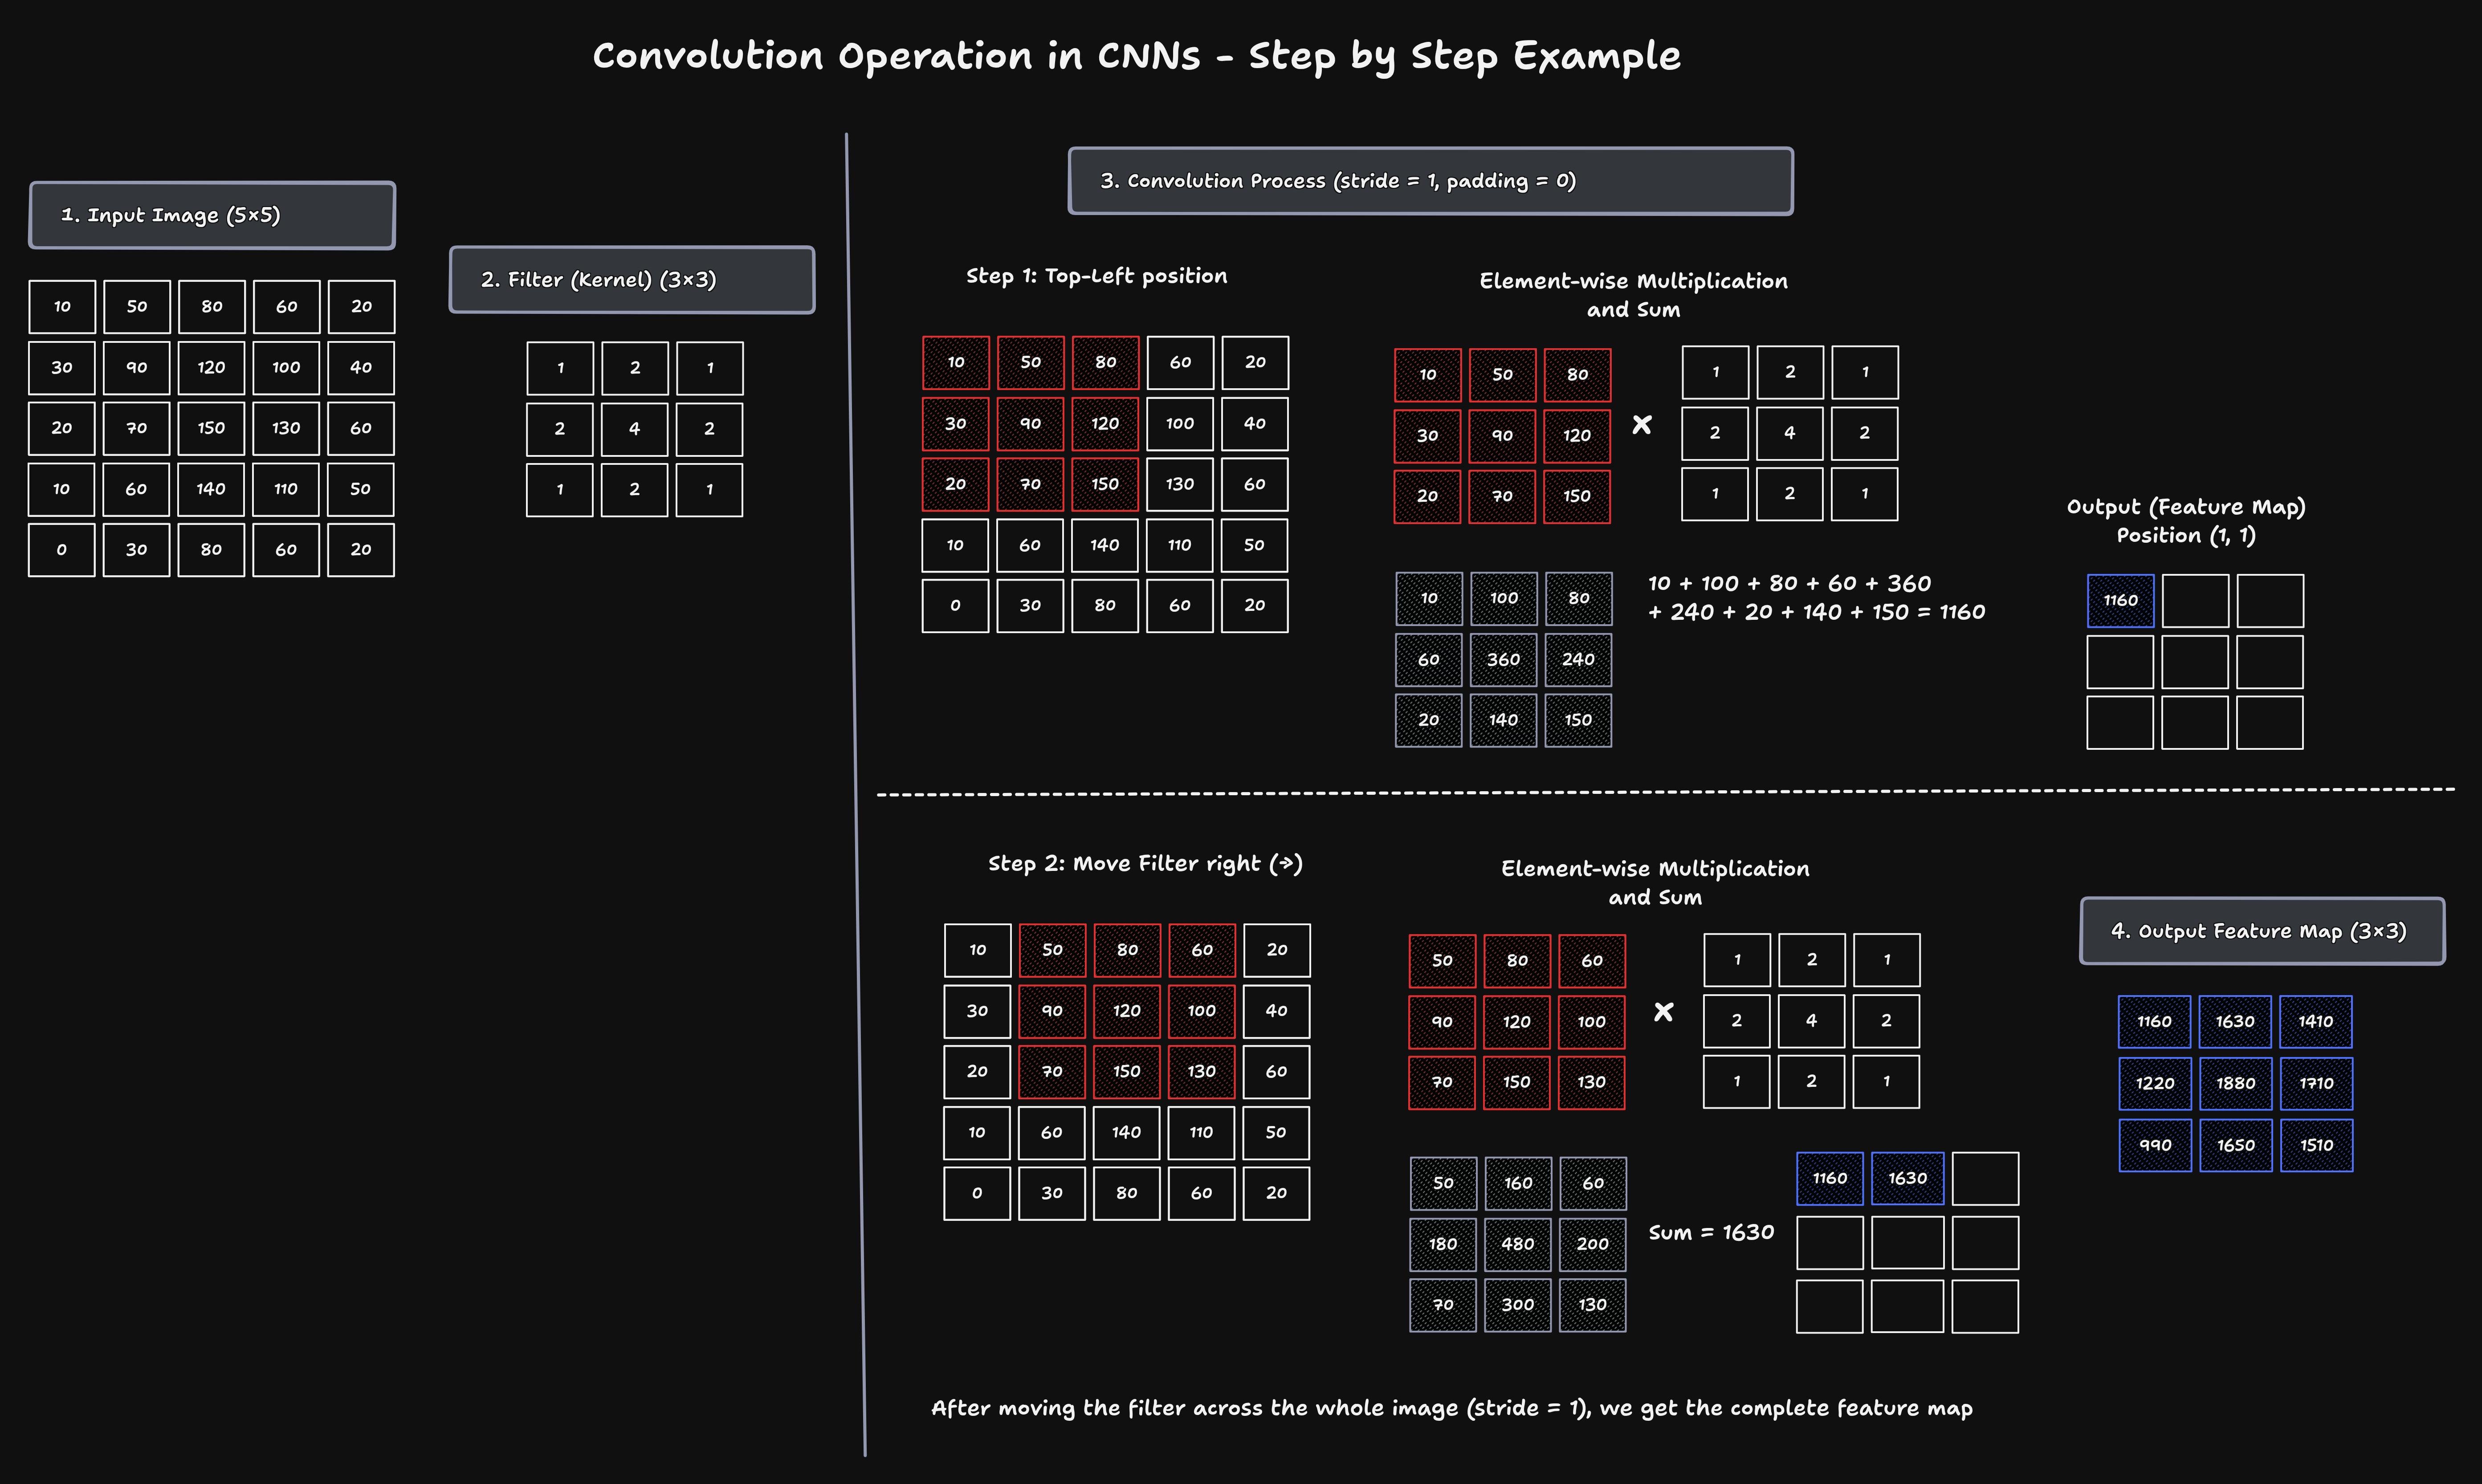

# Question 08: [ Marks 10 ]

## Explain the concept of pooling in CNNs. Compare MaxPooling and AveragePooling in terms of operation, advantages, and impact on feature extraction. Discuss how pooling helps in reducing overfitting and computational complexity.

## Write Answer 08:

### **Pooling in Convolutional Neural Networks (CNNs)**

Pooling is an important operation in Convolutional Neural Networks (CNNs). It is mainly used to reduce the size of the feature map while keeping the most useful information. After the convolution layer extracts features such as edges, textures, and shapes, the pooling layer summarizes those features into a smaller representation.

In simple words, pooling helps the network focus on the most important parts of an image and ignore unnecessary details.

For example, if a feature map is of size $4 × 4$, after applying a $2×2$ pooling filter, it may become $2×2$. This reduces the amount of data that needs to be processed in the next layers.

### **How Pooling Works**

A small window, such as $2×2$, moves over the feature map with a certain stride. For each region, a single value is selected based on the pooling method. The two most common types are:
* MaxPooling
* AveragePooling

### **1. MaxPooling**

MaxPooling selects the maximum value from each pooling region.

Example:

$$
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$

After MaxPooling:

$$4$$

Here, the maximum value 4 is selected.

**Advantages of MaxPooling**

MaxPooling is very useful when we want to keep the most important features from an image. It simply picks the highest value from a small region, so strong signals like edges or patterns are not lost. Because of this, the network becomes better at recognizing important details even if the image changes slightly.

**Impact on Feature Extraction**

MaxPooling highlights the most activated features, That means if an important feature appears in a region, MaxPooling preserves it. Because of this, it is widely used in image recognition tasks.

### **2. AveragePooling**

AveragePooling calculates the average value of each pooling region.

Example:

$$
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$

After AveragePooling:

$$
\frac{1+3+2+4}{4} = 2.5
$$

**Advantages of AveragePooling**

AveragePooling takes the average of all values in a region. This helps to keep the overall information of that area. It produces smoother outputs and can be useful when we care about the general presence of features rather than strong edges.

**Impact on Feature Extraction**

AveragePooling keeps the average information of a region, but it may reduce the strength of important features. So it is less effective than MaxPooling in capturing sharp patterns.

### **Comparison Between MaxPooling and AveragePooling**

$$
\begin{array}{|c|c|c|}
\hline
\textbf{Aspect} & \textbf{MaxPooling} & \textbf{AveragePooling} \\
\hline
\text{Operation} & \text{Takes maximum value} & \text{Takes average value} \\
\hline
\text{Main Focus} & \text{Strongest feature} & \text{Average Information} \\
\hline
\text{Feature Preservation} & \text{Preserves important features better} & \text{Smooths features} \\
\hline
\text{Common Usage} & \text{More commonly used} & \text{Less commonly used} \\
\hline
\end{array}
$$

### **How Pooling Reduces Overfitting**

Pooling reduces the size of feature maps, which means the next layers receive fewer values. This reduces the number of computations and parameters in the network. Because the model becomes simpler, it is less likely to memorize the training data. This helps reduce overfitting and improves generalization on unseen data. Also, pooling makes the network less sensitive to small shifts or distortions in the image, which improves robustness.

### **How Pooling Reduces Computational Complexity**

Pooling helps reduce computational complexity by decreasing the size of the feature maps. After convolution, the feature maps can be quite large, which means the next layers have to process a lot of values. When pooling is applied, it reduces the width and height of these maps by combining small regions into a single value.

Because of this reduction, the number of calculations in the following layers becomes much smaller. This makes the network faster and also reduces memory usage. As a result, training becomes more efficient, and the model can handle larger inputs more easily without increasing too much computational cost.



# Question 09: [ Marks 10 ]

## Given an input image of size 128×128×3, explain step-by-step how the dimensions change after multiple convolution and pooling layers. Clearly show calculations for output size after each layer using appropriate formulas.

# Write Answer 09:

### **Dimension Changes in CNN (Step-by-Step)**

We are given an input of size $ 128 × 128 × 3$, where 128 is the height and width, and 3 represents the color channels (RGB). In a CNN, the image passes through convolution and pooling layers, and the size changes step by step. Below is a clear explanation of how this happens.

### **Formula Used**

**For convolution:**

$$
\text{Output size} = \frac{N - F + 2P}{S} + 1
$$

Where:
* $N$ = input size
* $F$ = filter size
* $P$ = padding
* $S$ = stride

**For pooling:**

$$
\text{Output size} = \frac{N - F}{S} + 1
$$

### **Step 1: First Convolution Layer**

We apply:
* Filter size = $3×3$
* Stride = $1$
* Padding = $1$
* Number of filters = $32$

Now applying the formula:

$$
\frac{128-3+2(1)}{1} + 1 = 128
$$

So, height and width remain the same.

Output: $128 × 128 × 32$

**Explanation:** Padding adds extra pixels around the image, so even after applying the filter, the size does not decrease. However, since we used 32 filters, the depth increases from 3 to 32. Each filter creates one feature map.

### **Step 2: First Pooling Layer**

We apply:
* Pool size = $2×2$
* Stride = $2$

Now:

$$
\frac{128-2}{2} + 1 = 64
$$

Output: $64 × 64 × 32$

**Explanation:** Pooling reduces the spatial size. Here, each $2×2$ region becomes a single value, so the height and width are reduced by half. The depth remains the same because pooling does not change the number of channels.

### **Step 3: Second Convolution Layer**

We apply:
* Filter size = $3×3$
* Stride = $1$
* Padding = $1$
* Filters = $64$

Calculation:

$$
\frac{64-3+2(1)}{1} + 1 = 64
$$

Output: $64×64×64$

**Explanation:** Again, padding keeps the spatial size unchanged. But now we use 64 filters, so the depth increases from 32 to 64. This means the network is learning more complex features.

### **Step 4: Second Pooling Layer**

$$
\frac{64-2}{2} + 1 = 32
$$

Output: $32 × 32 × 64$

**Explanation:** Pooling again reduces height and width by half. The image becomes smaller but still keeps important features. Depth stays the same.

### **Step 5: Third Convolution Layer**

We apply:
* Filter size = $3×3$
* Stride = $1$
* Padding = $1$
* Filters = $128$

$$
\frac{32-3+2(1)}{1} + 1 = 32
$$

Output: $32×32×128$

**Explanation:** The size remains same due to padding, but depth increases to 128. This means the network is now capturing very detailed and high-level features.

### **6. Third Pooling Layer**

$$
\frac{32-2}{2} + 1 = 16
$$

Output: $16 × 16 × 128$

**Explanation:** Pooling reduces the spatial size again. Now the image is much smaller, but still contains important learned features. This reduction also helps in faster computation.

At the beginning, the image was large $(128×128×3).$ After passing through layers:
* Height and width gradually decreased due to pooling
* Depth increased due to more filters in convolution.

Final output becomes: $16 × 16 × 128$

# Question 10: [ Marks 20 ]

## Design and implement a deep Convolutional Neural Network (CNN) for a multi-class image classification problem using PyTorch. The network should consist of four convolutional blocks, where each block includes two convolution layers followed by activation and normalization, and a pooling layer at the end. The number of filters should increase progressively across blocks. After the convolutional part, flatten the feature maps and connect them to fully connected layers with dropout for regularization, and produce final outputs corresponding to K classes. Also explain the role of each part of the network in detail.

# Write Answer 10:

## **Deep CNN Project for Multi-Class Image Classification**

I implemented a deep Convolutional Neural Network (CNN) using PyTorch for a multi-class image classification problem. I used a real dataset from kaggle called [New Plant Diseases Dataset](https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset), which contains different types of plant leaf images.

### **Import and Setup**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import kagglehub

In [ ]:
# Download dataset from kaggle
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Dataset Path:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset Path: /kaggle/input/new-plant-diseases-dataset


In [ ]:
# Fix random seed for reproducibility
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Device:", device)

Using Device: cuda


I imported all the necessary libraries required for building and training the CNN model. I used PyTorch for deep learning tasks, torchvision for image transformations, PIL for loading images, and kagglehub to directly download the dataset from Kaggle.

After importing everything, I downloaded the dataset and checked the device. If a GPU is available, the model runs on GPU; otherwise it uses CPU. This is important because training deep learning model becomes much faster on a GPU compared to a CPU.

### **Data Preprocessing**

In [ ]:
base_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

# Defining dataset paths
TRAIN_PATH = os.path.join(base_dir, "train" )
VAL_PATH = os.path.join(base_dir, "valid")

print("Train Path:", TRAIN_PATH)
print("Validation Path:", VAL_PATH)

# Image preprocessing steps
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

Train Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


After setting up the environment, I defined the paths for the training and validation datasets.

Then I applied preprocessing steps using `transforms.Compse()`. First, all images are resized to $128×128$ because neural networks require fixed input size. After that, the images are converted into tensors so that PyTorch can process them.

Finally, I applied normalization to scale the pixel values. This helps the model train more efficiently and improves stability during learning by keeping the input values in a consistent range.

### **Custom Dataset Class**

In [ ]:
# Custom dataset class for loading images
class MultiClassDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.samples = [] # store (image_path, label)
    self.transform = transform

    # Get all class folder names
    self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    # Convert class names into numeric labels
    self.cls_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    # Store image paths with labels
    for class_name in self.classes:
      class_path = os.path.join(root_dir, class_name)
      for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)
        self.samples.append((img_path, self.cls_to_idx[class_name]))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, label = self.samples[idx]

    # Load image and convert to RGB
    image = Image.open(img_path).convert("RGB")

    # Apply transformation if available
    if self.transform:
      image = self.transform(image)

    return image, label


Next, I created a custom dataset class. This class is responsible for reading images from folders, assigning labels based on folder names, and returning image-label pairs.

First, I collected all class names from the dataset folder. Then I created a mapping from class names to numerical labels. After that, I looped through all images and stored their file paths along with their labels.

The `__getitem__` function loads each image, applies the transformation, and returns it with its label. This step is necessary because PyTorch requires data to be in a structured format.

### **DataLoader**

In [ ]:
# Load training and validation datasets
train_dataset_full = MultiClassDataset(TRAIN_PATH, transform)
test_dataset_full = MultiClassDataset(VAL_PATH, transform)

# Number of classes in dataset
num_classes = len(train_dataset_full.classes)

# Print dataset information for verification
print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))

Number of classes: 38
Full train size: 70295
Full test size: 17572


In [ ]:
# Create smaller subsets for faster training/testing
train_dataset = Subset(train_dataset_full, list(range(35000)))
test_dataset = Subset(test_dataset_full, list(range(8500)))

# Check if GPU is available for faster data loading
pin = True if device.type == 'cuda' else False

# DataLoader for training data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=pin)

# DataLoader for validation/testing data
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=pin)

After preparing the dataset, I loaded both the training and validation datasets using the custom dataset class. I also checked the total number of classes, training samples, and validation samples to make sure the dataset was loaded correctly.

Since the full dataset is large, I used a subset of it for faster training and testing during development. This helps reduce computation time while still allowing the model to learn patterns from the data.

Then I used `DataLoader` to load the data in batches. DataLoader is important because it helps in efficient memory usage, enables batching, and improves training performance. I enabled suffling for the training data so that the model does not learn in a fixed order, which improves generalization. For validation data, shuffling is disabled to maintain consistency during evaluation.

Finally, I used `pin_memory=True` when GPU is available, which speeds up data transfer from CPU to GPU.

### **CNN Model**

In [ ]:
# CNN Model Definition
class MyCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    # Convolutional feature extractor
    self.features = nn.Sequential(

      # Block 1: basic feature extraction
      nn.Conv2d(3, 32, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(32),
      nn.Conv2d(32, 32, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(32),
      nn.MaxPool2d(2),

      # Block 2: deeper features
      nn.Conv2d(32, 64, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(64),
      nn.Conv2d(64, 64, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(64),
      nn.MaxPool2d(2),

      # Block 3: complex patterns
      nn.Conv2d(64, 128, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(128),
      nn.Conv2d(128, 128, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(128),
      nn.MaxPool2d(2),

      # Block 4: high-level features
      nn.Conv2d(128, 256, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(256),
      nn.Conv2d(256, 256, 3, padding=1),
      nn.ReLU(),
      nn.BatchNorm2d(256),
      nn.MaxPool2d(2),
    )

    # Fully connected classifier
    self.classifier = nn.Sequential(
      nn.Flatten(), # convert feature map to vector
      nn.Linear(256*8*8, 256),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(256, 128),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.features(x)          # extract features
    x = self.classifier(x)         # classify features
    return x

I designed a deep CNN model that follows a structured pattern of four convolutional blocks. Each block contains two convolution layers followed by an activation and batch normalization. At the end of each block, a max pooling layer is used. This design helps the network gradually learn from simple features to more complex patterns.

At the beginning, the first convolution layer takes the input image with 3 channels (RGB) and applies 32 filters. Each filter tries to detect basic features such as edges or color transitions. After the convolution operation, I used ReLU activation function. The purpose of ReLU is to introduce non-linearity into the model so that it can learn complex relationships. Without activation functions, the network would behave like a simple linear model would not perform well.

After ReLU, batch normalization is applied. This layer normalizes the output values so that they remain in a stable range. It helps the model train faster and prevents problems like exploding or vanishing gradients. Then, another convolution layer is applied in the same block, which allows the model to refine the features learned in the previous layer. Again, ReLU and batch normalization are used for better learning.

At the end of each block, max pooling is applied. Pooling reduces the height and width of the feature map, which decreases computational cost and keeps only the important information. This process is repeated for four blocks, and in each block, the number of filters increases from 32 to 64, then 128, and finally 256. Increasing filters helps the network capture more complex and detailed features in deeper layers.

After completing all convolution blocks, the feature maps are flattened into a one-dimensional vector. This step is necessary because fully connected layers require input in vector form. Then, the data is passed through fully connected layers where actual classification happens. Between these layers, I used ReLU activation again and also applied dropout. Dropout randomly turns off some neurons during training, which helps prevent overfitting and improves generalization.

Finally, the last linear layer produces output values equal to the number of classes. These outputs represent the scores for each class, and the highest score determines the predicted class.

### **Training Setup**

In [ ]:
# Create model and move to device
model = MyCNN(num_classes).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

In the training setup, I first initialized the CNN model and moved it to the selected device, which can be either GPU or CPU. Using GPU is preferred because it speeds up the training process significantly.

Next, I selected the loss function as CrossEntropyLoss. This loss function is commonly used for multi-class classification problems because it compares predicted outputs with the true labels and calculates how far the prediction is from the correct answer.

After that, I chose the Adam optimizer. The optimizer is responsible for updating the weights of the model during training. Adam is a good choice because it automatically adjusts the learning rate and usually gives faster convergence compared to simple gradient descent.

I also set the learning rate to 0.001, which controls how big the update step will be during training. If the learning rate is too high, the model may not learn properly, and if it is too low, training becomes very slow. Finally, I defined the number of epochs, which means how many times the model will go through the entire training dataset.

### **Training Loop**

In [ ]:
for epoch in range(epochs):
  model.train()
  total_loss = 0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    # Gradient resets
    optimizer.zero_grad()

    # Predicted output
    outputs = model(images)

    # Loss computation
    loss = criterion(outputs, labels)

    # Backward pass
    loss.backward()

    # Update parameter
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.4244
Epoch 2, Loss: 0.7359
Epoch 3, Loss: 0.5156
Epoch 4, Loss: 0.3863
Epoch 5, Loss: 0.3306
Epoch 6, Loss: 0.2799
Epoch 7, Loss: 0.2257
Epoch 8, Loss: 0.2100
Epoch 9, Loss: 0.1825
Epoch 10, Loss: 0.1674


The training loop is the main part where the model actually learns. For each epoch, I first set the model to training mode using `model.train()`. This is important because certain layers like dropout and batch normalization behave differently during training and evaluation.

Then, I loop through the training data batch by batch using the DataLoader. For each batch, I move the images and labels to the device (GPU or CPU). After that, I perform a forward pass by passing the images through the model to get predictions.

Before computing gradients, I reset them using `optimizer.zero_grad()` because PyTorch accumulates gradients by default. Once the predictions are obtained, I calculate the loss using the loss function. This loss represents how far the model's predictions are from the actual labels.

Next is backpropagation, where I call `loss.backward()`. This step calculates gradients of the loss with respect to all model parameters. After that, I update the model parameters using `optimizer.step()`, which adjusts the weights to minimize the loss.

I also keep track of the total loss for each epoch and print the average loss at the end. This helps me understand whether the model is learning properly or not.

From the output, we can see that the loss decreases steadily from 1.4244 in Epoch 1 to around 0.1674 in Epoch 10. This is clearly shows that the model is learning properly over time and improving its predictions. At the beginning, the loss is higher because the model is still learning basic patterns from the data. As training continues, the loss keeps decreasing, which means the model is gradually making fewer mistakes.

The small fluctuations in later epochs are normal and expected. This usually happens when the model is close to convergence and is fine-tuning its weights to get better results.

### **Evaluation**

In [ ]:
# Function to evaluate model performance on validation/test data
def evaluate(loader):
  model.eval() # Set model to evaluation mode
  correct = 0 # count of correct predictions
  total = 0 # total number of samples

  # No gradient calculation needed during evaluation
  with torch.no_grad():
    for images, labels in loader:

      # Move data to GPU/CPU
      images, labels = images.to(device), labels.to(device)

      # Get model predictions
      outputs = model(images)

      # Get index of highest score
      _, predicted = torch.max(outputs, 1)

      # Update total number of samples
      total += labels.size(0)

      # Count how many predictions are correct
      correct += (predicted == labels).sum().item()

  # Return accuracy (Correct predictions / total samples)
  return correct / total

# Evaluate model on test data
accuracy = evaluate(test_loader)

# Print final accuracy result
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9731764705882353


This function is used to evaluate how well the trained model performs on unseen data (test or validation set).

First, I set the model to evaluation mode using `model.eval()`. This is important because layers like dropout and batch normalization behave differently during training and testing.

Then I disable gradient calculation using `torch.no_grad()`. This makes the evaluation faster and uses less memory because we do not need to update the model during testing.

Next. I loop through the test dataset batch by batch. For each batch, I move the images and labels to the selected device (GPU or CPU). After that, I pass the images through the model to get predictions.

The model output scores for each class, and I use `torch.max()` to select the class with the highest score as the final prediction.

Then I compare the predicted labels with the actual labels. If they match, I count it as a correct prediction. I keep track of the total number of samples and correct predictions.

Finally, I calculate accuray by dividing the number of correct predictions by the total number of samples.

From the output the test accuracy is 0.9731(97.31%). This is very high accuracy, which means the model is performing very well on unseen data. It correctly predicts almost 97 out of 100 samples. This shows that the model has learned the patterns in the dataset properly and is generalizing well without major overfitting.